# Data Preparation


In [3]:
import pandas
import numpy
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

#Dataset
df=pandas.read_csv(r"ml_data\final_ml_dataset_encoded.csv")
print(df.shape)
print(df.head())

#Separating features and target variable
X = df.drop(
    columns=[
        "loyalty_number",
        "cancelled_flag",
        "behavioral_churn",
        "final_churn"
    ]
)

y = df["final_churn"]

print("Features Shape :",X.shape)
print("\nTarget Variable Shape :",y.value_counts())

#Train Test Split
X_train,X_test,Y_train,Y_test=train_test_split(
    X,y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features Shape :",X_train.shape)
print("Testing Features Shape :",X_test.shape)
print("Training Target Variable:",Y_train.value_counts())
print("Testing Target Variable:",Y_test.value_counts())



(1000, 52)
   loyalty_number    salary      clv  redemption_rate  points_balance  \
0          768012  259461.0  5108.04         0.016147           75919   
1          471018   50047.0  4505.84         0.000000               0   
2          103862  299560.0  4878.83         0.038820           66505   
3          823048   80697.0  3919.37         0.000000           17990   
4          675879   78617.0  8000.55         0.003136          171956   

   active_month_count  inactive_month_count  consecutive_inactive_months  \
0                  17                     7                            1   
1                   0                    24                           24   
2                  14                    10                            0   
3                   5                    19                            1   
4                   7                     4                            0   

   months_since_last_flight  flights_last_3_months  ...  province_Nova Scotia  \
0           

# Models:

## Logistic Regression

### Train Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression
lr_model=LogisticRegression(max_iter=5000,random_state=42)
lr_model.fit(X_train,Y_train)
joblib.dump(lr_model, "logistic_regression_model.joblib")
print("Model Saved")

Model Saved


c:\Users\krish\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Predictions

In [14]:
Y_pred_lr=lr_model.predict(X_test)
Y_prob_lr=lr_model.predict_proba(X_test)[:, 1]

### Confusion Matrix


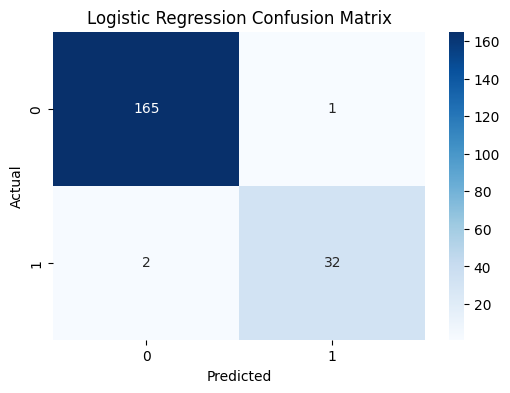

In [15]:
cm=confusion_matrix(Y_test,Y_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Classification Report

In [16]:
print("Classification Report:")
print(classification_report(Y_test, Y_pred_lr))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       166
           1       0.97      0.94      0.96        34

    accuracy                           0.98       200
   macro avg       0.98      0.97      0.97       200
weighted avg       0.98      0.98      0.98       200



### Evaluation Metrics

In [17]:
accuracy_lr=accuracy_score(Y_test,Y_pred_lr)
precision_lr=precision_score(Y_test,Y_pred_lr)
recall_lr=recall_score(Y_test,Y_pred_lr)
f1_lr=f1_score(Y_test,Y_pred_lr)
auc_lr=roc_auc_score(Y_test,Y_prob_lr)

print("Logistic Regression Performance:")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-Score: {f1_lr:.4f}")
print(f"AUC-ROC: {auc_lr:.4f}")


Logistic Regression Performance:
Accuracy: 0.9850
Precision: 0.9697
Recall: 0.9412
F1-Score: 0.9552
AUC-ROC: 0.9885


### ROC Curve

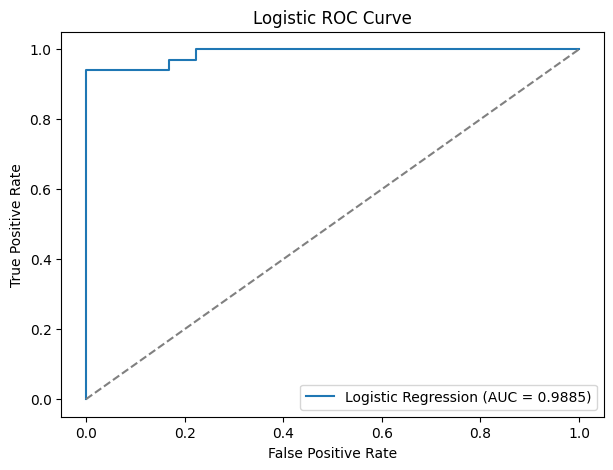

In [18]:
fpr, tpr, thresholds = roc_curve(Y_test, Y_prob_lr)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot([0,1],[0,1],linestyle='--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")    
plt.title("Logistic ROC Curve")
plt.legend()    
plt.show()

### Feature Importance Table

In [19]:
importance=pandas.DataFrame({
    "Feature:":X.columns,
    "Coefficient:":lr_model.coef_[0]
})
importance["Absolute Coefficient:"]=importance["Coefficient:"].abs()
importance=importance.sort_values(by="Absolute Coefficient:",ascending=False)   

print("Feature Importance:")
print(importance.head(15))

Feature Importance:
                       Feature:  Coefficient:  Absolute Coefficient:
7      months_since_last_flight      0.538597               0.538597
12   months_since_last_activity      0.538597               0.538597
4            active_month_count     -0.382081               0.382081
9         flights_last_6_months      0.210035               0.210035
5          inactive_month_count     -0.200675               0.200675
6   consecutive_inactive_months      0.159115               0.159115
8         flights_last_3_months     -0.092237               0.092237
45            loyalty_card_Star     -0.063896               0.063896
34    province_British Columbia     -0.059240               0.059240
11                tenure_months     -0.057719               0.057719
29       marital_status_Married      0.049383               0.049383
10       flights_last_12_months     -0.045136               0.045136
32           salary_band_Medium     -0.043030               0.043030
30        mari

### Feature Importance Graph

C:\Users\krish\AppData\Local\Temp\ipykernel_18952\177447074.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


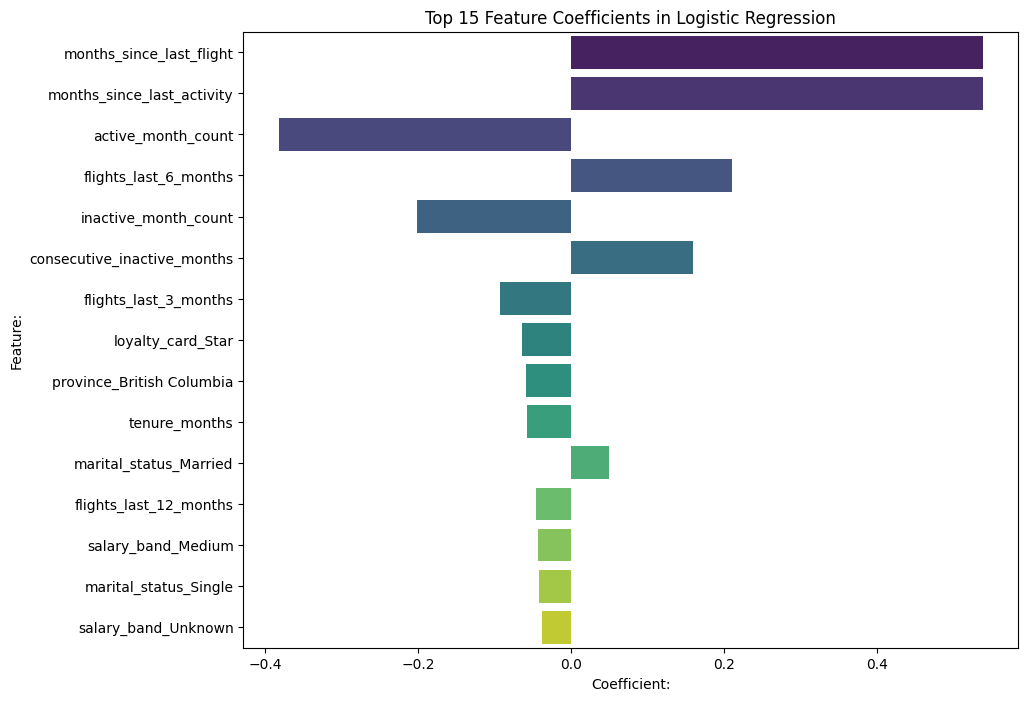

In [20]:
plt.figure(figsize=(10,8))
sns.barplot(
    x="Coefficient:",
    y="Feature:",
    data=importance.head(15),
    palette="viridis")

plt.title("Top 15 Feature Coefficients in Logistic Regression")
plt.show()


## Random Forest

### Train Random Forest

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    Y_train
)

joblib.dump(
    rf_model,
    "random_forest.pkl"
)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


### Predictions

In [22]:
Y_pred_rf = rf_model.predict(X_test)

Y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print(len(Y_test))
print(len(Y_pred_rf))
print(len(Y_prob_rf))

200
200
200


### Confusion Matrix

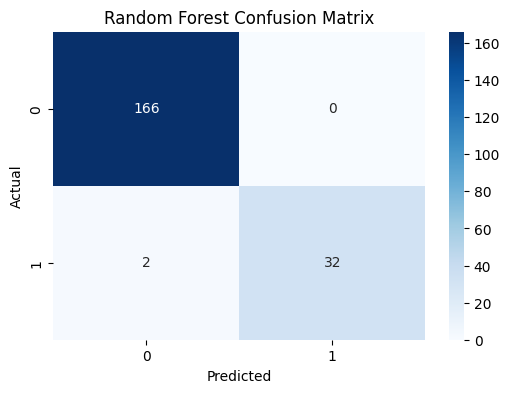

In [23]:
cm = confusion_matrix(
    Y_test,
    Y_pred_rf
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

### Classification Report

In [24]:
print(
    classification_report(
        Y_test,
        Y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       166
           1       1.00      0.94      0.97        34

    accuracy                           0.99       200
   macro avg       0.99      0.97      0.98       200
weighted avg       0.99      0.99      0.99       200



### Metrics

In [25]:
rf_acc = accuracy_score(
    Y_test,
    Y_pred_rf
)

rf_prec = precision_score(
    Y_test,
    Y_pred_rf
)

rf_rec = recall_score(
    Y_test,
    Y_pred_rf
)

rf_f1 = f1_score(
    Y_test,
    Y_pred_rf
)

rf_auc = roc_auc_score(
    Y_test,
    Y_prob_rf
)

print("Accuracy  :", round(rf_acc,4))
print("Precision :", round(rf_prec,4))
print("Recall    :", round(rf_rec,4))
print("F1 Score  :", round(rf_f1,4))
print("ROC-AUC   :", round(rf_auc,4))

Accuracy  : 0.99
Precision : 1.0
Recall    : 0.9412
F1 Score  : 0.9697
ROC-AUC   : 0.9833


### ROC Curve

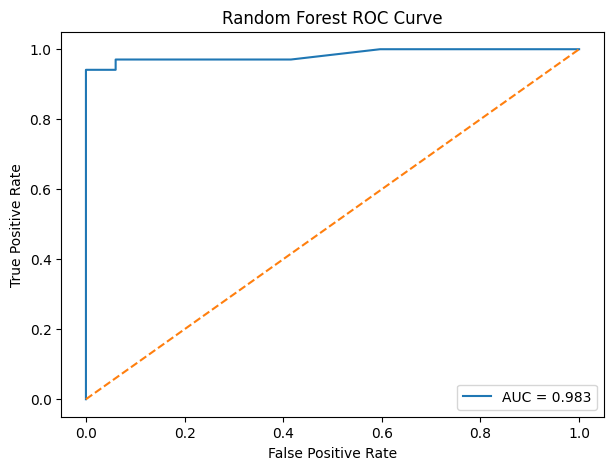

In [26]:
fpr, tpr, _ = roc_curve(
    Y_test,
    Y_prob_rf
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {rf_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Random Forest ROC Curve"
)

plt.legend()

plt.show()

### Feature Importance Table

In [28]:
rf_importance = pandas.DataFrame({

    "Feature": X.columns,

    "Importance":
    rf_model.feature_importances_
})

rf_importance = (
    rf_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

rf_importance.head(15)

,Feature,Importance
12,months_since_last_activity,0.144909
7,months_since_last_flight,0.123455
6,consecutive_inactive_months,0.120912
9,flights_last_6_months,0.091567
19,points_last_6_months,0.065681
14,distance_last_3_months,0.061287
18,points_last_3_months,0.058261
15,distance_last_6_months,0.058207
8,flights_last_3_months,0.047283
20,points_last_12_months,0.040666


### Feature Importance Graph

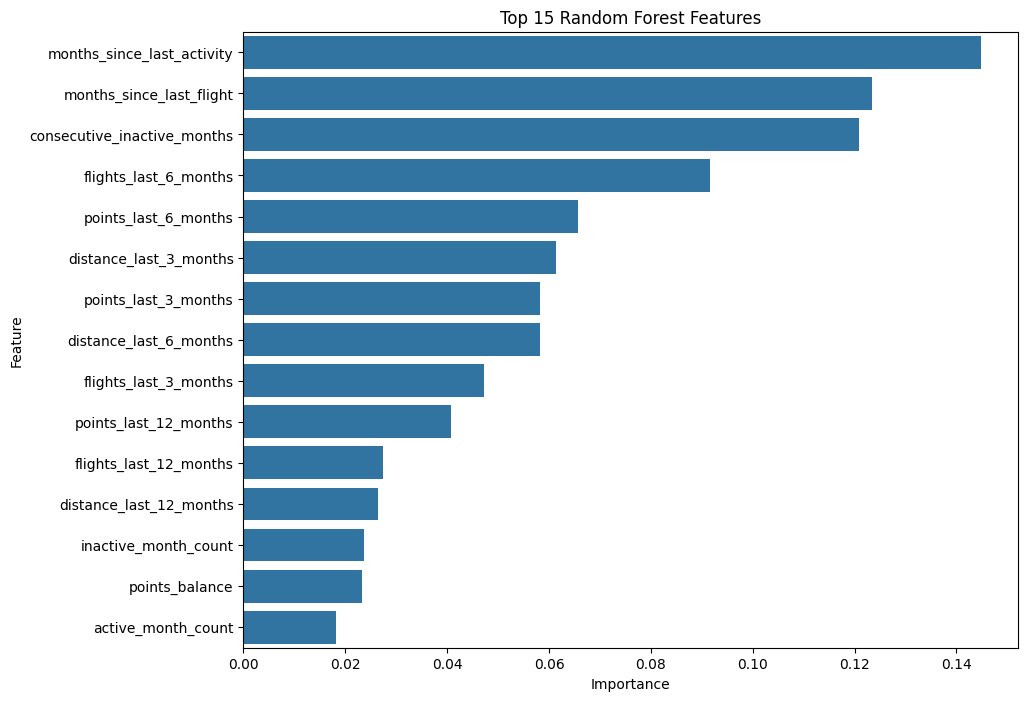

In [29]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=rf_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Random Forest Features"
)

plt.show()

## XGBoost

### Train XGBoost

In [4]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
   X_train,Y_train
)

joblib.dump(
    xgb_model,
    "xgboost.pkl"
)

print("XGBoost Model Trained Successfully")

XGBoost Model Trained Successfully


### Predictions

In [5]:
Y_pred_xgb = xgb_model.predict(X_test)

Y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

print(len(Y_test))
print(len(Y_pred_xgb))
print(len(Y_prob_xgb))

200
200
200


### Confusion Matrix

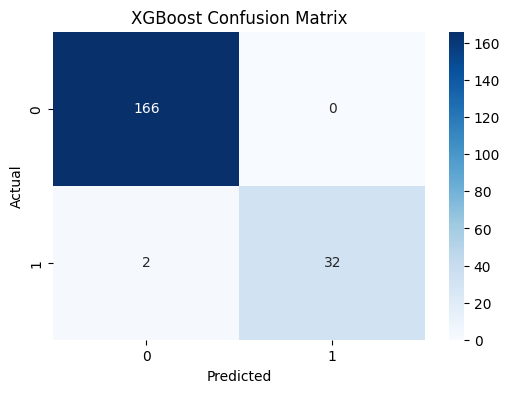

In [6]:
cm = confusion_matrix(
    Y_test,
    Y_pred_xgb
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "XGBoost Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

### Classification Report

In [7]:
print(
    classification_report(
        Y_test,
        Y_pred_xgb
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       166
           1       1.00      0.94      0.97        34

    accuracy                           0.99       200
   macro avg       0.99      0.97      0.98       200
weighted avg       0.99      0.99      0.99       200



### Metrics

In [8]:
xgb_acc = accuracy_score(
    Y_test,
    Y_pred_xgb
)

xgb_prec = precision_score(
    Y_test,
    Y_pred_xgb
)

xgb_rec = recall_score(
    Y_test,
    Y_pred_xgb
)

xgb_f1 = f1_score(
    Y_test,
    Y_pred_xgb
)

xgb_auc = roc_auc_score(
    Y_test,
    Y_prob_xgb
)

print("Accuracy  :", round(xgb_acc,4))
print("Precision :", round(xgb_prec,4))
print("Recall    :", round(xgb_rec,4))
print("F1 Score  :", round(xgb_f1,4))
print("ROC-AUC   :", round(xgb_auc,4))

Accuracy  : 0.99
Precision : 1.0
Recall    : 0.9412
F1 Score  : 0.9697
ROC-AUC   : 0.9826


### ROC Curve

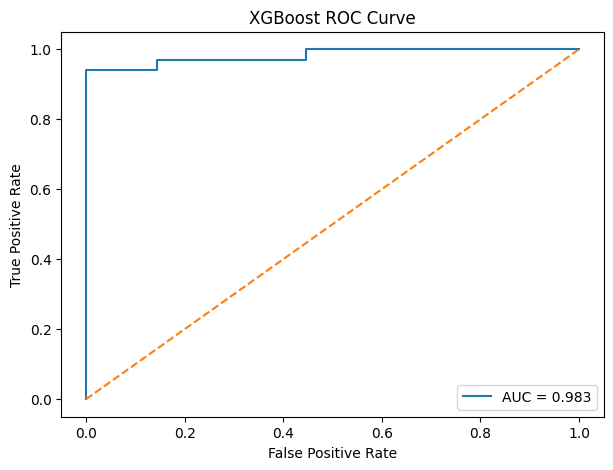

In [9]:
fpr, tpr, _ = roc_curve(
    Y_test,
    Y_prob_xgb
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {xgb_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "XGBoost ROC Curve"
)

plt.legend()

plt.show()

### Feature Importance Table

In [11]:
xgb_importance = pandas.DataFrame({

    "Feature": X.columns,

    "Importance":
    xgb_model.feature_importances_
})

xgb_importance = (
    xgb_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

xgb_importance.head(15)

,Feature,Importance
6,consecutive_inactive_months,0.288370
7,months_since_last_flight,0.284380
12,months_since_last_activity,0.121903
14,distance_last_3_months,0.033809
18,points_last_3_months,0.029026
4,active_month_count,0.024572
13,flight_activity_trend,0.018326
11,tenure_months,0.016730
47,clv_band_Medium CLV,0.014926
3,points_balance,0.010885


### Feature Importance Plot

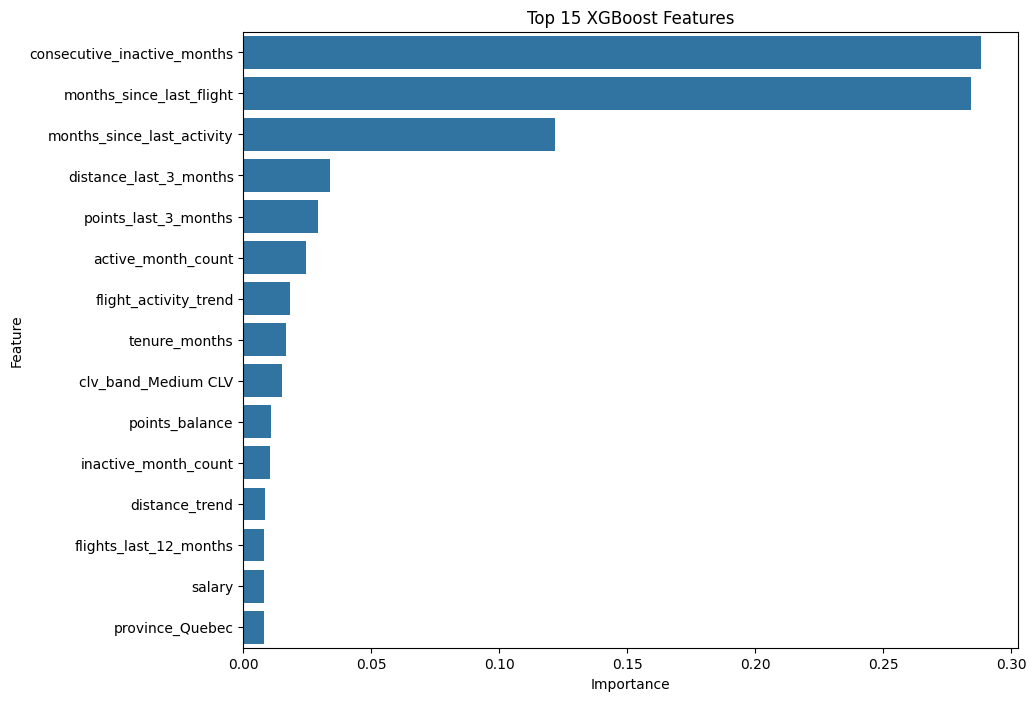

In [12]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=xgb_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 XGBoost Features"
)

plt.show()

## Model Comparison Table

In [ ]:
comparison = pand.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        log_acc,
        rf_acc,
        xgb_acc
    ],

    "Precision":[
        log_prec,
        rf_prec,
        xgb_prec
    ],

    "Recall":[
        log_rec,
        rf_rec,
        xgb_rec
    ],

    "F1 Score":[
        log_f1,
        rf_f1,
        xgb_f1
    ],

    "ROC_AUC":[
        log_auc,
        rf_auc,
        xgb_auc
    ]
})

comparison

NameError: name 'log_acc' is not defined